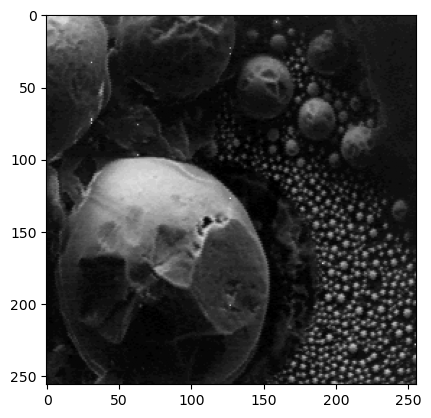

In [9]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/MEB.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

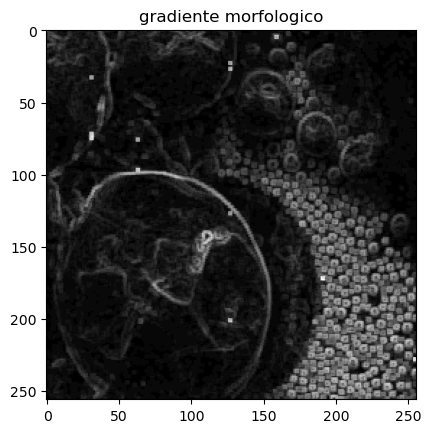

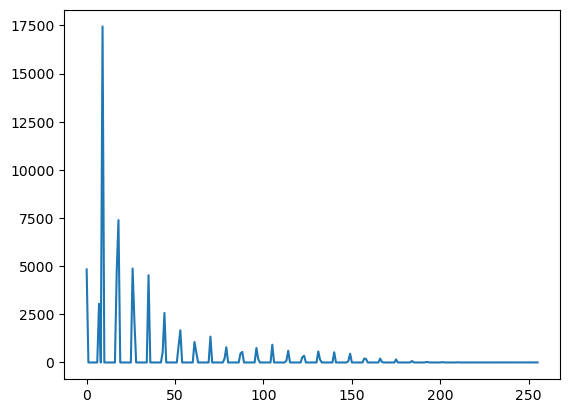

In [17]:
#Utilizando una máscara cuadrada de 3x3, calcule el gradiente morfológico de esta imagen.

from scipy.ndimage import morphological_gradient
import numpy as np

fp=np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])

mgimage = morphological_gradient(image, footprint=fp)
plt.imshow(mgimage, cmap="gray")
plt.title("gradiente morfologico")
plt.show()

from skimage import exposure


rescaled_img = exposure.rescale_intensity(mgimage, in_range=(mgimage.min(),mgimage.max()), out_range=(0,255))
rescaled_img = rescaled_img.astype(np.uint8)
hist_gradiente_morfologico = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist_gradiente_morfologico)
plt.show()



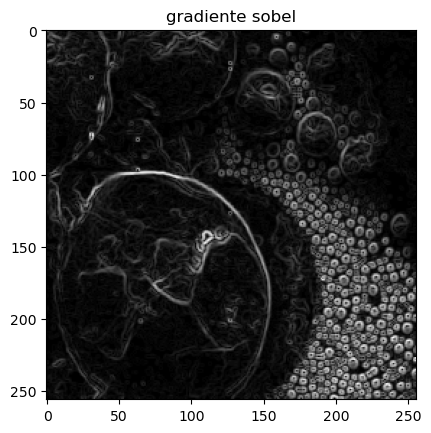

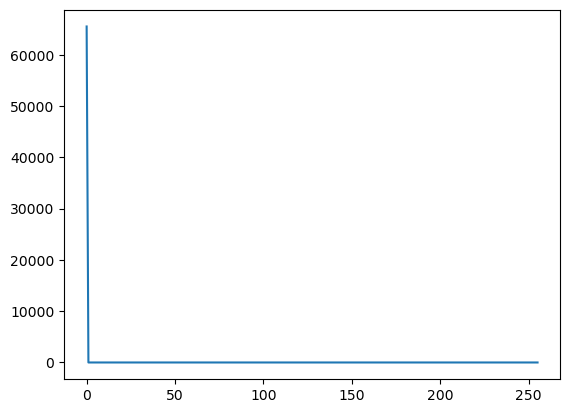

In [20]:
#Genere la imagen de la norma del gradiente de la imagen meb.png con el operador de Sobel

from skimage.filters import sobel_h, sobel_v, sobel

#Aplica el filtro Sobel horizontal
img_sh = sobel_h(image)
#Aplica el filtro Sobel vertical
img_sv = sobel_v(image)

gradiente_sobel = np.sqrt(img_sh**2 + img_sv**2)

plt.imshow(gradiente_sobel, cmap="gray")
plt.title("gradiente sobel")
plt.show()

from skimage import exposure


rescaled_img = exposure.rescale_intensity(gradiente_sobel, in_range=(mgimage.min(),mgimage.max()), out_range=(0,255))
rescaled_img = rescaled_img.astype(np.uint8)
hist_gradiente_sobel = cv2.calcHist([rescaled_img],[0],None,[256],[0,256])
plt.plot(hist_gradiente_sobel)
plt.show()


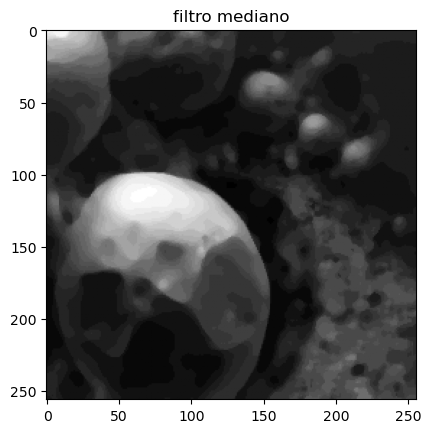

In [22]:
#Repita la operación 3 empleando la misma máscara, pero SIN utilizar el operador de gradiente morfológico (créelo con los operadores de dilatación y de erosión, precedidos por un filtrado mediano).

fp=np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])

from skimage.morphology import dilation, erosion, opening, closing

dilated_image = dilation(image, footprint=fp)
eroded_image = erosion(dilated_image, footprint=fp)


# filtrado mediano
from skimage import data
from skimage.morphology import disk, ball
from skimage.filters.rank import median
import numpy as np


med = median(eroded_image, disk(5))
plt.imshow(med, cmap="gray")
plt.title("filtro mediano")
plt.show()


